# **Day 19: Feature Engineering**
*Module 3 - Data Preparation and Feature Engineering*

"Coming up with features is difficult, time-consuming, requires expert knowledge. Applied machine learning is basically feature engineering." (Andrew Ng). Good features let **simple** models perform well and make results **explainable**. Domain knowledge is our competitive advantage.

> Feature engineering means creating new, more useful inputs from the raw data using domain knowledge. A good feature can improve a model more than a more complex algorithm.
>
> *Example:* Raw red and NIR bands are useful, but NDVI = (NIR - red) / (NIR + red) directly measures greenness and makes vegetation classes much easier to separate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
rng = np.random.default_rng(19)

## **1. Domain Features: Ratios and Indices**
A linear model cannot create a ratio by itself. If the physics says the signal is a **ratio**, give it the ratio.

Example: vegetation reflects strongly in NIR and absorbs red. The **NDVI** = (NIR - Red) / (NIR + Red) cancels illumination differences.

In [2]:
n = 1500
illum = rng.uniform(0.5, 1.5, n)                      # sun angle / topographic shading
veg_fraction = rng.uniform(0, 1, n)
red = illum * (0.25 - 0.20 * veg_fraction) + rng.normal(0, 0.005, n)
nir = illum * (0.30 + 0.25 * veg_fraction) + rng.normal(0, 0.005, n)
biomass = 120 * veg_fraction ** 1.5 + rng.normal(0, 5, n)
X_raw = pd.DataFrame({"red": red, "nir": nir})
X_eng = X_raw.assign(ndvi=(nir - red) / (nir + red), sr=nir / red)
for name, Xf in [("raw bands", X_raw), ("bands + NDVI + simple ratio", X_eng)]:
    print(f"{name:<28} CV R2 = {cross_val_score(LinearRegression(), Xf, biomass, cv=5).mean():.3f}")

raw bands                    CV R2 = 0.878
bands + NDVI + simple ratio  CV R2 = 0.968


## **2. Polynomial and Interaction Features**
`PolynomialFeatures(degree=2)` creates $x_1^2, x_2^2, x_1x_2$. Interactions model effects that depend on each other (fertiliser helps more when it rains).

In [3]:
from sklearn.preprocessing import PolynomialFeatures
fert = rng.uniform(0, 100, n); rain = rng.uniform(200, 1200, n)
yield_ = 1 + 0.002 * fert + 0.001 * rain + 0.00004 * fert * rain + rng.normal(0, 0.3, n)
Xi = pd.DataFrame({"fert": fert, "rain": rain})
print("Linear       R2:", cross_val_score(LinearRegression(), Xi, yield_, cv=5).mean().round(3))
print("With x1*x2   R2:", cross_val_score(make_pipeline(PolynomialFeatures(2, interaction_only=True), LinearRegression()), Xi, yield_, cv=5).mean().round(3))
pf = PolynomialFeatures(2).fit(Xi); print("Degree-2 features:", list(pf.get_feature_names_out()))

Linear       R2: 0.884
With x1*x2   R2: 0.954
Degree-2 features: ['1', 'fert', 'rain', 'fert^2', 'fert rain', 'rain^2']


Number of degree-$d$ features grows as $\binom{p+d}{d}$: 100 features at degree 3 gives 176,851 columns. Use regularisation (Day 24) or trees instead.

## **3. Binning and Splines**
Non-linear but smooth effects (temperature on crop growth is hump-shaped) can be modelled with **bins** (step function) or **splines** (smooth piecewise polynomials) while keeping a linear model.

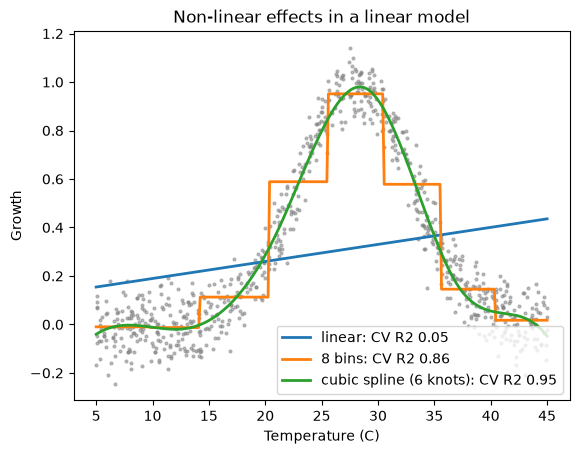

In [4]:
from sklearn.preprocessing import KBinsDiscretizer, SplineTransformer
temp = rng.uniform(5, 45, 800)
growth = np.exp(-((temp - 28) / 7) ** 2) + rng.normal(0, 0.08, 800)
T = temp[:, None]; grid = np.linspace(5, 45, 300)[:, None]
models = {"linear": LinearRegression(),
          "8 bins": make_pipeline(KBinsDiscretizer(8, encode="onehot-dense", quantile_method="averaged_inverted_cdf"), LinearRegression()),
          "cubic spline (6 knots)": make_pipeline(SplineTransformer(n_knots=6, degree=3), LinearRegression())}
plt.scatter(temp, growth, s=4, c="grey", alpha=0.5)
for name, m in models.items():
    m.fit(T, growth); plt.plot(grid, m.predict(grid), lw=2, label=f"{name}: CV R2 {cross_val_score(m, T, growth, cv=5).mean():.2f}")
plt.xlabel("Temperature (C)"); plt.ylabel("Growth"); plt.legend(); plt.title("Non-linear effects in a linear model"); plt.show()

## **4. Date and Time Features**

In [5]:
ts = pd.DataFrame({"timestamp": pd.date_range("2024-01-01", periods=8, freq="37h")})
ts = ts.assign(year=ts.timestamp.dt.year, month=ts.timestamp.dt.month, doy=ts.timestamp.dt.dayofyear,
               dow=ts.timestamp.dt.dayofweek, hour=ts.timestamp.dt.hour, is_weekend=ts.timestamp.dt.dayofweek >= 5,
               doy_sin=np.sin(2 * np.pi * ts.timestamp.dt.dayofyear / 365.25),
               doy_cos=np.cos(2 * np.pi * ts.timestamp.dt.dayofyear / 365.25),
               days_since_start=(ts.timestamp - ts.timestamp.min()).dt.days)
ts

,timestamp,year,month,doy,dow,hour,is_weekend,doy_sin,doy_cos,days_since_start
0,2024-01-01 00:00:00,2024,1,1,0,0,False,0.017202,0.999852,0
1,2024-01-02 13:00:00,2024,1,2,1,13,False,0.034398,0.999408,1
2,2024-01-04 02:00:00,2024,1,4,3,2,False,0.068755,0.997634,3
3,2024-01-05 15:00:00,2024,1,5,4,15,False,0.085906,0.996303,4
4,2024-01-07 04:00:00,2024,1,7,6,4,True,0.120126,0.992759,6
5,2024-01-08 17:00:00,2024,1,8,0,17,False,0.137185,0.990545,7
6,2024-01-10 06:00:00,2024,1,10,2,6,False,0.171177,0.985240,9
7,2024-01-11 19:00:00,2024,1,11,3,19,False,0.188099,0.982150,10


## **5. Aggregation (Group) Features**
Context from a group: a house's price relative to its neighbourhood average, a pixel's NDVI relative to its field mean, a customer's spend relative to their segment.

In [6]:
fields = pd.DataFrame({"field": rng.integers(0, 50, 2000), "ndvi": rng.uniform(0.2, 0.9, 2000)})
fields["ndvi_field_mean"] = fields.groupby("field").ndvi.transform("mean")
fields["ndvi_field_std"] = fields.groupby("field").ndvi.transform("std")
fields["ndvi_anomaly"] = fields.ndvi - fields.ndvi_field_mean
fields["field_size"] = fields.groupby("field").ndvi.transform("size")
fields.head()

,field,ndvi,ndvi_field_mean,ndvi_field_std,ndvi_anomaly,field_size
0,34,0.860296,0.555908,0.202171,0.304387,48
1,20,0.851572,0.555996,0.225094,0.295576,42
2,25,0.437070,0.562104,0.194303,-0.125034,40
3,39,0.747318,0.489706,0.220658,0.257612,30
4,21,0.263515,0.573955,0.176357,-0.310440,54


**Leakage warning:** group statistics that include the **target** (e.g. mean yield of the field) must be computed out-of-fold, exactly like target encoding (Day 18).

## **6. Text Features**

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
docs = ["flood water covered the rice fields", "drought reduced rice yield",
        "heavy rain caused flood damage", "good rain improved the yield"]
cv = CountVectorizer(stop_words="english").fit(docs)
print(pd.DataFrame(cv.transform(docs).toarray(), columns=cv.get_feature_names_out()))
tf = TfidfVectorizer(stop_words="english").fit(docs)
print("\nTF-IDF weights (rare words weigh more):\n", pd.DataFrame(tf.transform(docs).toarray(), columns=tf.get_feature_names_out()).round(2))

   caused  covered  damage  drought  fields  flood  good  heavy  improved  \
0       0        1       0        0       1      1     0      0         0   
1       0        0       0        1       0      0     0      0         0   
2       1        0       1        0       0      1     0      1         0   
3       0        0       0        0       0      0     1      0         1   

   rain  reduced  rice  water  yield  
0     0        0     1      1      0  
1     0        1     1      0      1  
2     1        0     0      0      0  
3     1        0     0      0      1  

TF-IDF weights (rare words weigh more):
    caused  covered  damage  drought  fields  flood  good  heavy  improved  \
0    0.00     0.49    0.00     0.00    0.49   0.38  0.00   0.00      0.00   
1    0.00     0.00    0.00     0.56    0.00   0.00  0.00   0.00      0.00   
2    0.49     0.00    0.49     0.00    0.00   0.38  0.00   0.49      0.00   
3    0.00     0.00    0.00     0.00    0.00   0.00  0.56   0.00      

## **7. Signal and Image Features**
From a raw signal (a time series of NDVI, an accelerometer trace, an image patch) we compute **summary statistics**, **texture** and **frequency** features.

In [8]:
from scipy import signal as sps
def signal_features(x, fs=1.0):
    f, p = sps.periodogram(x, fs=fs)
    return {"mean": x.mean(), "std": x.std(), "min": x.min(), "max": x.max(), "range": np.ptp(x),
            "skew": pd.Series(x).skew(), "slope": np.polyfit(np.arange(len(x)), x, 1)[0],
            "dominant_freq": f[1:][p[1:].argmax()], "zero_crossings": np.sum(np.diff(np.sign(x - x.mean())) != 0)}

t = np.arange(120)
classes = {"single crop (1 peak/yr)": 0.5 + 0.3 * np.sin(2 * np.pi * t / 120),
           "double crop (2 peaks/yr)": 0.5 + 0.3 * np.sin(4 * np.pi * t / 120),
           "forest (stable)": 0.8 + 0.0 * t}
feats = pd.DataFrame({k: signal_features(v + rng.normal(0, 0.03, 120)) for k, v in classes.items()}).T
feats.round(3)

,mean,std,min,max,range,skew,slope,dominant_freq,zero_crossings
single crop (1 peak/yr),0.497,0.213,0.131,0.848,0.717,-0.001,-0.005,0.008,5.0
double crop (2 peaks/yr),0.500,0.215,0.121,0.852,0.731,-0.004,-0.002,0.017,7.0
forest (stable),0.800,0.029,0.718,0.868,0.150,-0.183,-0.000,0.017,58.0


### Texture: the Grey-Level Co-occurrence Matrix (GLCM)
Texture describes spatial patterns: smooth water vs rough forest vs regular urban grids. The GLCM counts how often grey level $i$ occurs next to grey level $j$; statistics of it (contrast, homogeneity) are classic texture features (Haralick et al., 1973).

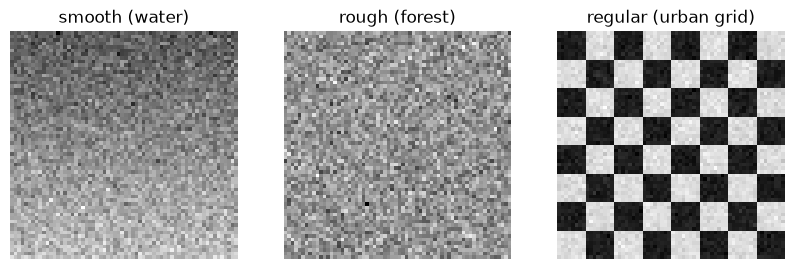

,contrast,homogeneity,energy,entropy
smooth (water),0.985,0.680,0.080,3.969
rough (forest),1.568,0.619,0.101,3.748
regular (urban grid),3.598,0.722,0.138,3.250


In [9]:
def glcm_features(img, levels=8, dx=1):
    q = np.floor((img - img.min()) / (np.ptp(img) + 1e-9) * (levels - 1)).astype(int)    # quantise
    a, b = q[:, :-dx].ravel(), q[:, dx:].ravel()                                          # horizontal neighbours
    P = np.zeros((levels, levels)); np.add.at(P, (a, b), 1); P = P + P.T; P /= P.sum()
    i, j = np.indices(P.shape)
    return {"contrast": np.sum(P * (i - j) ** 2), "homogeneity": np.sum(P / (1 + np.abs(i - j))),
            "energy": np.sum(P ** 2), "entropy": -np.sum(P[P > 0] * np.log2(P[P > 0]))}

yy, xx = np.mgrid[0:64, 0:64]
patches = {"smooth (water)": rng.normal(0, 0.05, (64, 64)) + yy / 300,
           "rough (forest)": rng.normal(0, 1, (64, 64)),
           "regular (urban grid)": ((xx // 8 + yy // 8) % 2).astype(float) + rng.normal(0, 0.05, (64, 64))}
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (k, v) in zip(axes, patches.items()):
    ax.imshow(v, cmap="gray"); ax.set_title(k); ax.axis("off")
plt.show()
pd.DataFrame({k: glcm_features(v) for k, v in patches.items()}).T.round(3)

# **Part 2: Going Deeper - Automated Feature Generation**

Generating thousands of candidate features automatically (all ratios, all pairwise products, all window statistics) and letting the model choose is tempting. Risks: **multiple-comparison overfitting** (Day 11, 16), slow training, and uninterpretable models. Always validate on held-out data and regularise.

In [10]:
from itertools import combinations
base = pd.DataFrame(rng.normal(size=(300, 12)), columns=[f"f{i}" for i in range(12)])
y_auto = base.f0 * base.f1 + rng.normal(0, 0.5, 300)              # true signal: one interaction
gen = base.copy()
for a, b in combinations(base.columns, 2):
    gen[f"{a}*{b}"] = base[a] * base[b]
print("Generated features:", gen.shape[1])
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
print("Base features CV R2     :", cross_val_score(ridge, base, y_auto, cv=5).mean().round(3))
print("All pairwise products R2:", cross_val_score(ridge, gen, y_auto, cv=5).mean().round(3))
coef = pd.Series(ridge.fit(gen, y_auto)[-1].coef_, index=gen.columns).abs().sort_values(ascending=False)
print("Top 3 features found:", list(coef.index[:3]))

Generated features:

 78
Base features CV R2     : -0.018
All pairwise products R2: 0.621
Top 3 features found: ['f0*f1', 'f11', 'f0*f10']


## **Practice Problems**
1. In the NDVI example, add the **EVI-like** feature `2.5 * (nir - red) / (nir + 2.4 * red + 1)`. Does R2 improve further?
2. Fit the temperature-growth data with `PolynomialFeatures(4)` + linear regression. Compare with the spline.
3. Create a feature "number of days since the last rain > 10 mm" from a daily rainfall series.
4. *(Advanced)* Generate all pairwise **ratios** (not products) of the 12 base features. Why are ratios dangerous? (Hint: division by values near zero.)

In [11]:
# Solution 1
X_eng2 = X_eng.assign(evi=2.5 * (nir - red) / (nir + 2.4 * red + 1))
print("With EVI-like:", cross_val_score(LinearRegression(), X_eng2, biomass, cv=5).mean().round(3))
# Solution 2
print("Poly-4:", cross_val_score(make_pipeline(PolynomialFeatures(4), LinearRegression()), T, growth, cv=5).mean().round(3))
# Solution 3
rain_d = pd.Series(rng.gamma(0.5, 8, 60))
wet = rain_d > 10
days_since = wet.groupby(wet.cumsum()).cumcount()
print(pd.DataFrame({"rain": rain_d.round(1), "days_since_heavy_rain": days_since}).head(12).T)
# Solution 4
ratio = base.f0 / base.f1
print("Max |ratio|:", ratio.abs().max().round(1), "-> extreme values when the denominator is near 0; use (a-b)/(a+b) on positive data")

With EVI-like: 0.968
Poly-4: 0.69
                         0    1    2     3    4    5    6    7    8    9   \
rain                   11.8  1.7  1.9  17.7  9.3  1.6  1.8  0.8  1.4  1.8   
days_since_heavy_rain   0.0  1.0  2.0   0.0  1.0  2.0  3.0  4.0  5.0  6.0   

                        10   11  
rain                   2.5  0.2  
days_since_heavy_rain  7.0  8.0  
Max |ratio|: 220.0 -> extreme values when the denominator is near 0; use (a-b)/(a+b) on positive data


## **Key References**
- Domingos, P. (2012). A few useful things to know about machine learning. *Communications of the ACM*, 55(10), 78-87.
- Zheng, A., & Casari, A. (2018). *Feature Engineering for Machine Learning*. O'Reilly.
- Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press (free online).
- Rouse, J. W. et al. (1974). Monitoring vegetation systems in the Great Plains with ERTS. *NASA SP-351*, 309-317 (origin of NDVI).
- Eilers, P. H. C., & Marx, B. D. (1996). Flexible smoothing with B-splines and penalties. *Statistical Science*, 11(2), 89-121.